# What tells a live mite from a dead one? A screen of four hypotheses

The analysis calls a mite alive up to its last movement, and a movement is a high score within one recording of 0.7 seconds. A live mite is still in four recordings out of five, so most of what the camera sees of a live mite says nothing by that score. This notebook asks what else in the pictures tells a live mite from a dead one, whether or not it moves.

Four hypotheses were tried on the long run (`test_run_2026-09-08_Mathis_last_dsRNA`, 295 recordings 10 minutes apart, every mite labelled in every recording), each with a handful of measurements (`scripts/alive_dead_features.py`):

1. **A mite shrinks when it dies.** Its dark shape gets smaller than it was. → `alive_dead_shrinkage.ipynb`
2. **A dead mite looks different.** One picture is enough, without the mite's past: its shape, its darkness, the sharpness of its outline.
3. **A live mite is never quite still.** Within a recording labelled still, the pixels of a live mite vary in a more orderly way than the camera's noise. → `alive_dead_hidden_motion.ipynb`
4. **A live mite's position changes between recordings.** Its centre moves or its long axis turns from one recording to the next. (The legs themselves are followed in `alive_dead_legs.ipynb`.)

They are set beside what is already known from `dead_mite_change.ipynb`: the whole image of a live mite changes from one recording to the next.

The first run cuts the patches and measures them (a few minutes); later ones start at once. The classifier needs scikit-learn, which is not in `discobox_env.yaml`.

## Findings (run of 8 October 2026)

One run, one plate, 54 mites that moved at least once. Alive: the recordings up to a mite's last labelled movement; dead: those 100 recordings or more after it.

- **Hypothesis 1 holds, and strongly.** The silhouette against the highest level the mite has had so far separates alive from dead with an AUC of 0.995, and 1.000 among the mites of the same recording. A dead mite's silhouette is about 7% smaller than it was. It is slow: it confirms a death hours later.
- **Hypothesis 2 mostly fails.** A classifier on seven measurements of one picture reaches an AUC of 0.71 on mites it has not seen (0.83 among the mites of the same recording); the same seven against the mite's own start reach 0.97. Mites differ in size by 13%, and a dead one is 6% smaller than itself.
- **Hypothesis 3 fails.** The best measurement of it reaches 0.83 pooled, and 0.70 among the mites of the same recording: most of it is a change of the run itself at about 20 hours. Around the death nothing steps.
- **Hypothesis 4 fails against what is already there.** The centre of a live mite moves a little more than a dead one's between recordings (AUC 0.71), its axis does not turn more (0.54). The change of the whole image does far better (0.985): what a live mite changes between recordings, presumably its legs, moves neither its centre nor its axis by much.
- **The two that hold are wrong in different places.** The image change takes 12% of the alive recordings for dead; of those, 95% are not shrunk. Only 0.6% of the alive recordings and 0.04% of the dead ones are wrong by both.
- **Two of the measurements show why a pooled AUC is not enough.** The brightness of the plate around a mite, which has nothing to do with the mite, separates alive from dead nine times in ten among the mites of the same recording, because the 8 mites that live longest sit on darker plate. The order of the noise in time separates them pooled, because the run changes at 20 hours.

**What follows.** The silhouette is worth having in the analysis as a second opinion on every death: it costs one number per mite and recording, from the mean image already in hand. And both it and the image change say that many mites live for hours after their last labelled movement (`alive_dead_shrinkage.ipynb`), which is a question for how a death is dated, not for which score is used.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

import alive_dead_features as adf
from optuna_death_time import MAX_PAD

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

# Chart style, as in death_time_calibration.ipynb: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3dc"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
COLORS = {"alive": ORANGE, "alive_moving": ORANGE, "alive_still": AQUA, "waiting": GREY, "dead": BLUE}
pd.set_option("display.precision", 3)

run = adf.load_run()
table, images = adf.features(run)   # {feature: (mites, recordings)}, and each mite's mean image per recording
group = adf.groups(run)
n_mites, n_recordings = run.moving.shape
last, moved = run.last, run.moved
step = float(np.median(np.diff(run.times)))  # minutes from one recording to the next
print(f"{run.name}: {n_mites} mites, {n_recordings} recordings {step:g} minutes apart; "
      f"{moved.sum()} mites moved at least once, {(~moved).sum()} never")
print("recordings: " + ", ".join(f"{name} {int(mask.sum())}" for name, mask in group.items()))

  test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings


test_run_2026-09-08_Mathis_last_dsRNA: 59 mites, 295 recordings 10 minutes apart; 54 mites moved at least once, 5 never
recordings: alive 3393, alive_still 2739, alive_moving 651, dead 7191, waiting 5346, never 1475


## How a measurement is judged

**Alive**: the recordings up to a mite's last labelled movement. **Dead**: those 100 recordings (1000 minutes) or more after it, where `dead_mite_change.ipynb` found the image no longer changing. The recordings in between (**waiting**) and the mites never labelled moving are left out of the comparison. For a measurement that compares a recording with the one before, both have to be in the group.

In this run alive and dead are not only alive and dead: the alive recordings are the early ones, and the mites that live long are not spread evenly over the plate. So three AUCs are given for every measurement (the chance that an alive recording has the higher value: 0.5 says nothing, 0 or 1 separates fully):

- **AUC**: all the recordings pooled.
- **same time**: alive and dead mites compared within the same recording, averaged over the recordings. Nothing that drifts with the hours can separate them here. A mite is dead from 100 recordings after its last movement, so this comparison only exists from recording 104 on, when 8 mites are still alive: it is a check, and it rests on those 8.
- **same mite**: each mite's alive recordings against its own dead ones, averaged over the mites. Nothing that differs from mite to mite can separate them here.

A measurement is taken at its word only where the three agree; **weakest** is the one of the three nearest to 0.5, read from whichever side (0.2 counts as 0.8). **distance** is the gap between the medians of the two groups in units of their own spread (d').

In [2]:
between = ("image_change", "moved_by", "turned_by", "silhouette_change")
measurements = {
    # hypothesis, name: values
    ("1 shrinking", "silhouette, below its highest so far"): adf.below_highest(table["silhouette"]),
    ("1 shrinking", "silhouette, since the start"): adf.since_start(table["silhouette"]),
    ("1 shrinking", "area 15% darker than the plate, since the start"): adf.since_start(table["area_15"]),
    ("1 shrinking", "elongation, since the start"): adf.since_start(table["elongation"]),
    ("2 one picture", "silhouette, in pixels"): table["silhouette"],
    ("2 one picture", "area 15% darker than the plate, in pixels"): table["area_15"],
    ("2 one picture", "darkness of the 30 darkest pixels"): table["peak"],
    ("2 one picture", "elongation"): table["elongation"],
    ("2 one picture", "steepness of the outline"): table["edge"],
    ("2 one picture", "brightness of the plate around the mite"): table["plate"],
    ("3 hidden motion", "movement score in use"): table["movement_score"],
    ("3 hidden motion", "order of the noise in time"): table["order"],
    ("3 hidden motion", "trend over the frames"): table["trend"],
    ("3 hidden motion", "change between the two halves of the frames"): table["half_change"],
    ("3 hidden motion", "share of one pattern"): table["one_pattern"],
    ("4 position", "centre moved since the recording before"): table["moved_by"],
    ("4 position", "long axis turned since the recording before"): table["turned_by"],
    ("4 position", "silhouette changed since the recording before"): table["silhouette_change"],
    ("known", "image changed since the recording before"): table["image_change"],
}
pair_names = {"centre moved since the recording before", "long axis turned since the recording before",
              "silhouette changed since the recording before", "image changed since the recording before"}

def sides(name, positive="alive", negative="dead"):
    return (adf.both(group[positive]), adf.both(group[negative])) if name in pair_names else (group[positive], group[negative])

rows = []
for (hypothesis, name), values in measurements.items():
    result = adf.separation(values, *sides(name))
    aucs = [result["auc"], result["same_time"], result["same_mite"]]
    rows.append({"hypothesis": hypothesis, "measurement": name, "AUC": result["auc"], "same time": result["same_time"],
                 "same mite": result["same_mite"], "weakest": min(max(a, 1 - a) for a in aucs) if (min(aucs) > 0.5 or max(aucs) < 0.5) else 0.5,
                 "distance": abs(result["distance"])})
screen = pd.DataFrame(rows).sort_values("weakest", ascending=False).set_index(["hypothesis", "measurement"])
display(screen)

AUC  \
hypothesis      measurement                                              
1 shrinking     silhouette, below its highest so far             0.995   
known           image changed since the recording before         0.985   
1 shrinking     silhouette, since the start                      0.962   
                area 15% darker than the plate, since the start  0.959   
2 one picture   area 15% darker than the plate, in pixels        0.721   
3 hidden motion order of the noise in time                       0.834   
1 shrinking     elongation, since the start                      0.305   
3 hidden motion trend over the frames                            0.697   
4 position      centre moved since the recording before          0.713   
                silhouette changed since the recording before    0.695   
2 one picture   brightness of the plate around the mite          0.407   
3 hidden motion change between the two halves of the frames      0.635   
2 one picture   silhouette, in pixels                            0.614   
3 hidden motion movement score in use                            0.485   
2 one picture   steepness of the outline                         0.426   
                elongation                                       0.463   
                darkness of the 30 darkest pixels                0.458   
3 hidden motion share of one pattern                             0.438   
4 position      long axis turned since the recording before      0.541   

                                                                 same time  \
hypothesis      measurement                                                  
1 shrinking     silhouette, below its highest so far                 1.000   
known           image changed since the recording before             0.990   
1 shrinking     silhouette, since the start                          0.967   
                area 15% darker than the plate, since the start      0.978   
2 one picture   area 15% darker than the plate, in pixels            0.771   
3 hidden motion order of the noise in time                           0.700   
1 shrinking     elongation, since the start                          0.314   
3 hidden motion trend over the frames                                0.643   
4 position      centre moved since the recording before              0.631   
                silhouette changed since the recording before        0.615   
2 one picture   brightness of the plate around the mite              0.104   
3 hidden motion change between the two halves of the frames          0.579   
2 one picture   silhouette, in pixels                                0.541   
3 hidden motion movement score in use                                0.436   
2 one picture   steepness of the outline                             0.283   
                elongation                                           0.675   
                darkness of the 30 darkest pixels                    0.382   
3 hidden motion share of one pattern                                 0.523   
4 position      long axis turned since the recording before          0.459   

                                                                 same mite  \
hypothesis      measurement                                                  
1 shrinking     silhouette, below its highest so far                 0.998   
known           image changed since the recording before             0.975   
1 shrinking     silhouette, since the start                          0.983   
                area 15% darker than the plate, since the start      0.986   
2 one picture   area 15% darker than the plate, in pixels            0.986   
3 hidden motion order of the noise in time                           0.841   
1 shrinking     elongation, since the start                          0.190   
3 hidden motion trend over the frames                                0.711   
4 position      centre moved since the recording before              0.728   
               

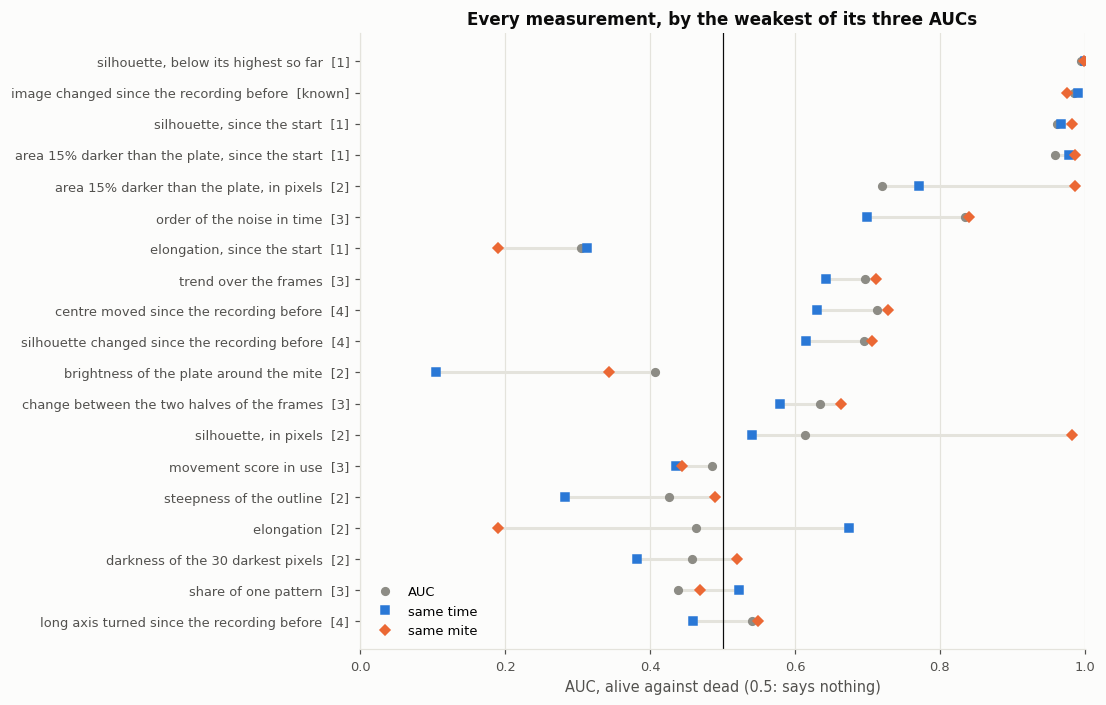

In [3]:
shown = screen.reset_index()
fig, ax = plt.subplots(figsize=(8.5, 0.33 * len(shown) + 1))
at = np.arange(len(shown))[::-1]
for column, color, marker in (("AUC", GREY, "o"), ("same time", BLUE, "s"), ("same mite", ORANGE, "D")):
    ax.plot(shown[column], at, marker, color=color, markersize=5, label=column)
ax.hlines(at, shown[["AUC", "same time", "same mite"]].min(axis=1), shown[["AUC", "same time", "same mite"]].max(axis=1), color=GRID, linewidth=2, zorder=0)
ax.axvline(0.5, color=INK, linewidth=0.8)
ax.set_yticks(at)
ax.set_yticklabels([f"{row.measurement}  [{row.hypothesis[0] if row.hypothesis != 'known' else 'known'}]" for row in shown.itertuples()], fontsize=8.5)
ax.set(xlim=(0, 1), xlabel="AUC, alive against dead (0.5: says nothing)", title="Every measurement, by the weakest of its three AUCs")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left")
plt.show()

## Why the three AUCs: two measurements that are not what they seem

**The brightness of the plate around the mite** has nothing to do with the mite. Yet among the mites of one recording, the dead ones sit on brighter plate than the live ones nine times in ten. The plate is not lit evenly, and the 8 mites that live past recording 104 happen to sit on its darker parts. Any measurement that goes with the brightness (the camera's noise does, and so every score built on it) inherits that when mites are compared with each other. Below, each mite's plate brightness against its last labelled movement.

**The order of the noise in time** separates alive from dead with a pooled AUC of 0.8. Most of that is the clock: something in the run changes at about 20 hours for every mite, dead or alive (`alive_dead_hidden_motion.ipynb`).

plate brightness around the 8 mites alive past recording 104: median 111 (105 to 115); around the others: median 116, middle half 112 to 120; rank correlation over all mites -0.18


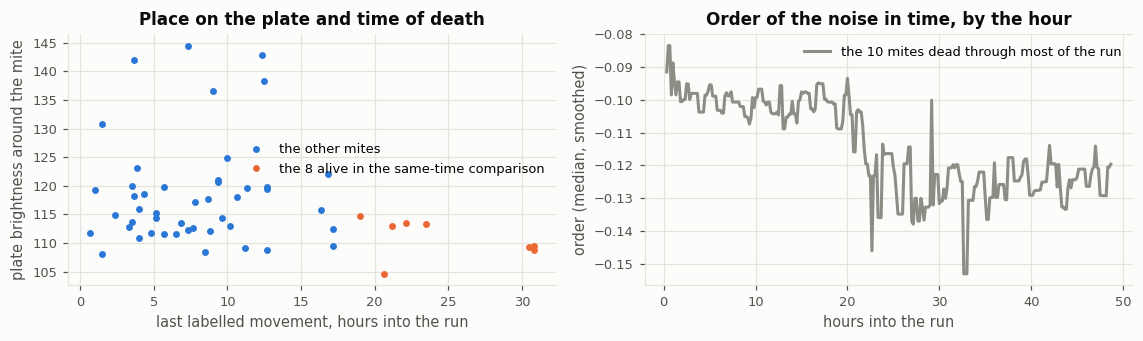

In [4]:
from scipy.stats import spearmanr

brightness = np.median(table["plate"], axis=1)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.2))
long_lived = moved & (last >= adf.LONG_DEAD + last[moved].min())   # alive when the first mite counts as dead
axes[0].plot(run.times[last[moved & ~long_lived]] / 60, brightness[moved & ~long_lived], ".", color=BLUE, markersize=7, label="the other mites")
axes[0].plot(run.times[last[long_lived]] / 60, brightness[long_lived], ".", color=ORANGE, markersize=7,
             label=f"the {long_lived.sum()} alive in the same-time comparison")
axes[0].set(xlabel="last labelled movement, hours into the run", ylabel="plate brightness around the mite",
            title="Place on the plate and time of death")
axes[0].legend()
print(f"plate brightness around the {long_lived.sum()} mites alive past recording {adf.LONG_DEAD + last[moved].min()}: median "
      f"{np.median(brightness[long_lived]):.0f} ({brightness[long_lived].min():.0f} to {brightness[long_lived].max():.0f}); around the others: "
      f"median {np.median(brightness[moved & ~long_lived]):.0f}, middle half {np.percentile(brightness[moved & ~long_lived], 25):.0f} to "
      f"{np.percentile(brightness[moved & ~long_lived], 75):.0f}; rank correlation over all mites {spearmanr(last[moved], brightness[moved])[0]:.2f}")
dead_all_along = (~moved) | (last < 15)
axes[1].plot(run.times / 60, pd.Series(np.median(table["order"][dead_all_along], axis=0)).rolling(5, center=True).median(), color=GREY,
             label=f"the {dead_all_along.sum()} mites dead through most of the run")
axes[1].set(xlabel="hours into the run", ylabel="order (median, smoothed)", title="Order of the noise in time, by the hour")
axes[1].legend()
plt.tight_layout()
plt.show()

## Hypothesis 2: can one picture tell, without the mite's past?

The shrinking (hypothesis 1) is read against the mite's own earlier pictures. If a dead mite simply looked different from a live one, a single picture would do, and the mites never seen moving could be called too. Each measurement of one picture alone is in the table above; here they are put together: a gradient-boosted classifier on all of them, trained on four fifths of the mites and judged on the fifth it has not seen, five times over. A second one gets the same measurements against the mite's start, to show what the past adds.

In [5]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GroupKFold

def held_out(columns, positive, negative, folds=5):
    """Each recording's chance of being alive by a classifier that has not seen
    its mite: (mites, recordings), nothing outside the two groups."""
    mask = positive | negative
    mite_of = np.broadcast_to(np.arange(n_mites)[:, None], mask.shape)[mask]
    features = np.column_stack([values[mask] for values in columns])
    target = positive[mask]
    predicted = np.zeros(mask.sum())
    for train, test in GroupKFold(folds).split(features, target, mite_of):
        model = HistGradientBoostingClassifier(max_depth=3, max_iter=150, learning_rate=0.08, random_state=0)
        predicted[test] = model.fit(features[train], target[train]).predict_proba(features[test])[:, 1]
    out = np.full(mask.shape, np.nan)
    out[mask] = predicted
    return out

one_picture = [table[name] for name in ("silhouette", "area_15", "area_30", "peak", "size", "elongation", "edge")]
with_past = [adf.since_start(values) for values in one_picture]
rows = []
for name, columns in (("one picture: 7 measurements of it", one_picture),
                      ("the same 7, each against the mite's start", with_past)):
    result = adf.separation(held_out(columns, group["alive"], group["dead"]), group["alive"], group["dead"])
    rows.append({"classifier on": name, "AUC": result["auc"], "same time": result["same_time"], "same mite": result["same_mite"]})
display(pd.DataFrame(rows).set_index("classifier on"))
print(f"mites differ in size more than a mite shrinks: their silhouettes at the start spread by "
      f"{100 * np.std(np.median(table['silhouette'][:, :3], axis=1)) / np.mean(np.median(table['silhouette'][:, :3], axis=1)):.0f}% "
      f"of the mean, a dead mite's is {-100 * np.median(adf.since_start(table['silhouette'])[group['dead']]):.0f}% under its start in the middle")

,AUC,same time,same mite
classifier on,,,
one picture: 7 measurements of it,0.711,0.834,0.735
"the same 7, each against the mite's start",0.974,0.965,0.988


mites differ in size more than a mite shrinks: their silhouettes at the start spread by 13% of the mean, a dead mite's is 6% under its start in the middle


## Hypothesis 4: does a live mite's position or direction change between recordings?

`dead_mite_change.ipynb` compares the whole image of a mite with the one in the recording before. If what changes is where the mite is or which way it points, two numbers would say it more plainly and with less noise: how far its centre moved and how far its long axis turned, the plate's own shift taken out. Below, each against the whole-image change, for the pairs of recordings in which the mite is alive in both, and dead in both.

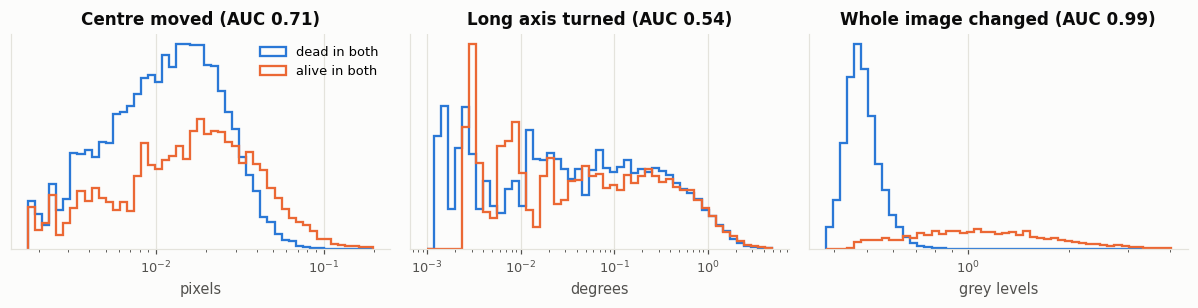

a dead mite's centre is found within 0.020 px of where it was (median), a live one's within 0.034 px


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.9))
for ax, (title, values, unit) in zip(axes, (("Centre moved", table["moved_by"], "pixels"),
                                            ("Long axis turned", np.degrees(table["turned_by"]), "degrees"),
                                            ("Whole image changed", table["image_change"], "grey levels"))):
    alive_pairs, dead_pairs = values[adf.both(group["alive"])], values[adf.both(group["dead"])]
    low, high = np.nanpercentile(np.concatenate([alive_pairs, dead_pairs]), [0.5, 99.5])
    bins = np.geomspace(max(low, 1e-3), high, 50)
    ax.hist(dead_pairs, bins=bins, density=True, histtype="step", linewidth=1.5, color=COLORS["dead"], label="dead in both")
    ax.hist(alive_pairs, bins=bins, density=True, histtype="step", linewidth=1.5, color=COLORS["alive"], label="alive in both")
    ax.set_xscale("log")
    ax.set_yticks([])
    ax.set(xlabel=unit, title=f"{title} (AUC {adf.auc(alive_pairs, dead_pairs):.2f})")
axes[0].legend()
plt.tight_layout()
plt.show()
print(f"a dead mite's centre is found within {np.nanmedian(table['moved_by'][adf.both(group['dead'])]):.3f} px of where it was (median), "
      f"a live one's within {np.nanmedian(table['moved_by'][adf.both(group['alive'])]):.3f} px")

## The two that hold, together

The image change between recordings (known) and the silhouette below its highest (new) are judged above on the same recordings. They measure different things, at different speeds: the first says *this mite did something in the last 10 minutes*, the second *this mite has been dead for a while*. Where one is wrong, is the other?

image changed: by more than 0.75 grey levels; shrunk: more than 4.2% below its highest



,recordings,image changed,shrunk,taken for dead by both,taken for alive by both
,,,,,
alive recordings,3339,88.1%,2.6%,0.63%,-
dead recordings,7137,0.4%,97.4%,-,0.04%


of the 397 alive recordings whose image did not change, 95% are not shrunk: the silhouette says the mite is not dead yet


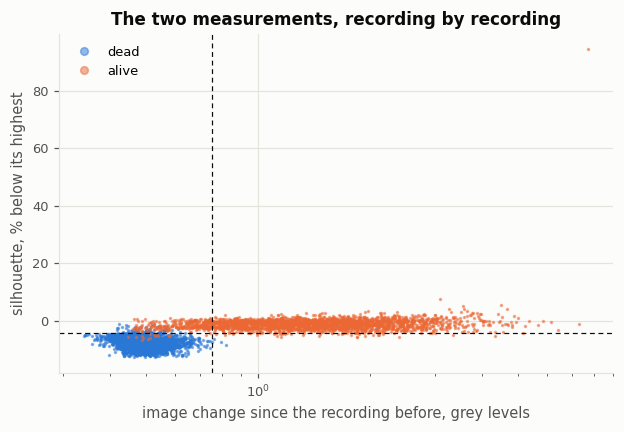

,AUC,same time,same mite
,,,
image change alone,0.985,0.99,0.975
silhouette below its highest alone,0.995,1.00,0.998
"both, by a classifier on mites it has not seen",0.996,1.00,0.998


In [7]:
below = 100 * adf.below_highest(table["silhouette"])
change = table["image_change"]
alive_pairs, dead_pairs = adf.both(group["alive"]), adf.both(group["dead"])
CHANGE_LIMIT = float(np.percentile(table["noise_floor"][run.labelled & ~run.moving], 99.9))   # as dead_mite_change.ipynb
limits = np.arange(-8, 0.01, 0.1)
SHRUNK_LIMIT = float(limits[int(np.argmax([(below[group["dead"]] < limit).mean() + (below[group["alive"]] >= limit).mean() for limit in limits]))])
changed, shrunk = change > CHANGE_LIMIT, below < SHRUNK_LIMIT
print(f"image changed: by more than {CHANGE_LIMIT:.2f} grey levels; shrunk: more than {-SHRUNK_LIMIT:.1f}% below its highest\n")
rows = [
    {"": "alive recordings", "recordings": int(alive_pairs.sum()), "image changed": f"{changed[alive_pairs].mean():.1%}",
     "shrunk": f"{shrunk[alive_pairs].mean():.1%}", "taken for dead by both": f"{(~changed & shrunk)[alive_pairs].mean():.2%}"},
    {"": "dead recordings", "recordings": int(dead_pairs.sum()), "image changed": f"{changed[dead_pairs].mean():.1%}",
     "shrunk": f"{shrunk[dead_pairs].mean():.1%}", "taken for alive by both": f"{(changed & ~shrunk)[dead_pairs].mean():.2%}"},
]
display(pd.DataFrame(rows).set_index("").fillna("-"))
unchanged_alive = alive_pairs & ~changed
print(f"of the {int(unchanged_alive.sum())} alive recordings whose image did not change, {(~shrunk)[unchanged_alive].mean():.0%} are not shrunk: "
      f"the silhouette says the mite is not dead yet")

sample = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(6.5, 4))
for name, pairs in (("dead", dead_pairs), ("alive", alive_pairs)):
    index = np.flatnonzero(pairs.ravel())
    index = sample.choice(index, min(2500, len(index)), replace=False)
    ax.plot(change.ravel()[index], below.ravel()[index], ".", color=COLORS[name], markersize=2.5, alpha=0.5, label=name)
ax.axvline(CHANGE_LIMIT, color=INK, linewidth=0.8, linestyle=(0, (4, 3)))
ax.axhline(SHRUNK_LIMIT, color=INK, linewidth=0.8, linestyle=(0, (4, 3)))
ax.set_xscale("log")
ax.set(xlabel="image change since the recording before, grey levels", ylabel="silhouette, % below its highest",
       title="The two measurements, recording by recording")
ax.legend(markerscale=4)
plt.show()

together = held_out([np.log(change), below], alive_pairs, dead_pairs)
rows = [{"": name, **{key: value for key, value in adf.separation(values, alive_pairs, dead_pairs).items() if key != "distance"}}
        for name, values in (("image change alone", change), ("silhouette below its highest alone", below),
                             ("both, by a classifier on mites it has not seen", together))]
display(pd.DataFrame(rows).set_index("").rename(columns={"auc": "AUC", "same_time": "same time", "same_mite": "same mite"}))